# **Class Imbalance Lab 1**

### Authors:  Mariel Concepcion, Lorenzo De Villa, Bingbong Manglicmot, Caitlin Sebastian, JF Viray
### Learning Team: 7
---

In [ ]:
# Core
# Utils
from typing import Dict, Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import ADASYN, SMOTE, KMeansSMOTE, RandomOverSampler

# Imbalanced learning
from imblearn.under_sampling import RandomUnderSampler, TomekLinks


# Preprocessing & Pipeline
from sklearn.model_selection import (
    train_test_split,
)

from model import FraudDetector

# **1. Executive Summary**

CreditByte is a mid-sized financial services company, which struggles with fraud since criminals bypass traditional rule-based systems.  For example, many fraudulent transactions are small in amount, making them difficult to flag with just a simple threshold check. Given this complication, our main objective is to help improve the current business process in identifying fraudulent transactions in order to minimize cost. 

We propose a business process with a human in the loop. First, a Random Forest model will be used to improve fraud detection with particular attention to the heavy class imbalance between the 305 fraudulent and 180,149 non-fraudulent samples. To mitigate this imbalance, we experimented with various sampling methods to improve the model’s ability to correctly identify fraud cases. Namely, they are Random Oversampling, Random Undersampling, SMOTE, ADASYN, Tomek-Links, and Class Weighting. 

Among the sampling methods tested, Random Undersampling achieved the highest recall of 93%, but this came at the cost of terrible precision (53%), leading to many non-fraudulent transactions being incorrectly flagged. By contrast, SMOTE delivered a lower recall of 91% but significantly improved precision to 94%, representing a more balanced trade-off between recall and precision. In terms of monetary savings, SMOTE is also a more practical and business-friendly choice since the company saves 3,341 USD; unlike random undersampling that has a loss of 238,896 USD. The team further built on SMOTE by combining it with other strategies but only improved marginally. Overall, our findings demonstrate how machine learning with sampling methods can enhance fraud detection for CreditByte. 

Finally, we incorporate a LIME-based explanation for a flagged transaction so that CreditByte’s investigators can easily understand why a transaction was identified as fraudulent. This ensures that our model’s predictions remain transparent and interpretable, enabling investigators to make informed judgments while maintaining oversight in the overall fraud detection process.


(The project environment is set up with Python version 3.12.8.)

---

# **2. Introduction** 
In the financial industry, credit card fraud has become a pressing issue, with consumers losing $12.5 billion in 2024 alone (Federal Trade Commission, 2025). To counter this, financial services have been utilizing machine learning to detect fraud, thereby saving both consumers and providers from losses. 


<p align="center">
  <img src="figures/01_businessprocess.png"" alt="Business Processes" width="800"/>
</p>

<b><i> Figure 1.</b> Current (a) and Proposed (b) Business Process in Determining Fraud Transactions</i>

However, CreditByte, a financial services company, has continued to rely on traditional rule-based systems as shown in Figure 1a. These methods, such as flagging questionably large transactions, are no longer reliable as will be shown later in the report. Such strategies make these threshold-based methods ineffective and emphasizes the need for more intelligent and data-driven approaches. 

This report is guided by three main objectives: 

1. To understand why older methods of thresholding and flagging unusual transaction amounts are ineffective using EDA and a new business metric

2. To improve the current business process by having more accurate predictions of fraudulent transactions using various rebalancing strategies 

3. To do a LIME-based explanation of why a transaction was flagged for CreditByte’s investigators. 

In applying the various resampling methods for CreditByte's fraud detection, we built a model that both improves technical and business metrics to maximize company financial gains.  Ultimately, we propose a new business process in Figure 1b so that CreditByte can fight against adaptive fraud strategies. The main difference relies on the method used to classify a transaction as fraud, where we propose to use machine learning and a local interpretability method to further explain why it was flagged. 


---

# **3. Methodology**



<p align="center">
  <img src="figures/02_businessprocess.png"" alt="Methodology" width="800"/>
</p>

<b><i> Figure 2.</b> Overview of the Methodology</i>

## **3.1 Perform Exploratory Data Analysis**
Historical transaction records on fraud cases were taken from CreditByte. The dataset included anonymized PCA-transformed features (V1-V28), transaction amounts, and outcomes (fraud or non-fraud). Its dataset contains 185,124 rows by 31 columns. 

Data Dictionary: 

| Feature | Description | Data Type |
| :--- | :--- | :--- |
| **tid** | Unique transaction ID | Integer |
| **V1 – V28** | Principal Components resulting from masking sensitive features | Float |
| **Amount** | Transaction amount in USD | Float |
| **outcome** | Target Variable (Binary): 0 = Non-fraud, 1 = Fraud | Integer |


EDA was conducted to explore patterns that differentiate fraudulent from non-fraudulent transactions, providing insights into why simple thresholding may be ineffective and which machine learning models may be useful.


## **3.2 Evaluate Threshold-Based Fraud Detection**
We introduced a new metric, Net Savings, to evaluate the financial impact of how fraud was detected. We also tested on multiple thresholds, which ranged from the minimum to the maximum fraud transaction amounts, to evaluate how well simple thresholding captures fraudulent transactions.


## **3.3 Implement Random Forest for Prediction**
Random Forest was implemented since we identified it as the most effective model for predicting fraudulent transactions.


## **3.4 Identify and handle Class Imbalance**
After analyzing the results of the EDA, several sampling strategies were tested to mitigate the problem of class imbalance. Standard methods including random undersampling, random oversampling, SMOTE, etc., were applied first. To maximize these methods, additional hybrid approaches were integrated with the best standard method found. These approaches include:
KMeans-based resampling: Clustering minority instances prior to oversampling for more diversification 
Tomek links: Removing questionable majority samples for clearer class boundaries 
Hybrid Class weighting: Combines oversampling with penalty-based learning by assigning higher weights to minority class errors
Proportional sampling: Balancing the ratio between majority and minority transactions 

Apart from the standard business and technical evaluation metrics (recall, precision, F1-score, detection rate, fraud capture rate, etc.), we introduced a new business metric called net value. Such implementation allows quantification of the financial implications of classification results. 


## **3.5 Explain Predictions using LIME**
We created a method called ```explain_why_fraud``` to the FraudDetector class. It takes in a transaction that was flagged as fraudulent and outputs the LIME explainer table. While LIME explains individual fraud predictions, the following exploratory data analysis and business metric evaluation show why traditional threshold-based methods fail to capture the broader patterns of fraudulent behavior.


# **4. Results and Discussion**


## **4.1 Exploratory Data Analysis**


The data shows a massive imbalance between legitimate and fraudulent transactions. Out of 180,000 records, only 305 were fraudulent (less than 0.2%). This is a big challenge for traditional fraud detection.

Current rule-based detection systems, which flag transactions above a fixed amount, are no longer effective for this data(Vedešin, 2025). Our analysis shows that fraudulent transactions are smaller than legitimate ones. In fact, normal transactions can go above $10,000, but most fraudulent activities are below $1,000.

This pattern suggests that fraudsters keep their transactions small to avoid triggering automated alerts. So, relying on static threshold rules will leave CreditByte exposed to undetected losses. To fix this, we need more adaptive and data-driven detection methods that look at behavioral patterns rather than just transaction amount. 


In [3]:
df = pd.read_csv("historical.csv")

# Drop tid because it is just a unique id
df = df.drop(columns=["tid"])

<p align="center">
  <img src="figures/02_histograms.png"" alt="Class Histplot" width="1000"/>
</p>

<b><i> Figure 3.</b> Histogram of Non-Fraudelent (a) and Fraudelent (b) Transaction Amounts </i>

Beyond transaction amounts, the underlying data features represented as principal components show different behaviors. Legitimate transactions show no correlation, and fraud shows strong correlation across multiple variables. So, fraud is a consistent relationship across multiple variables. This indicates that fraudulent

<p align="center">
  <img src="figures/04_heatmap.png"" alt="Correlation Heatmap" width="1000"/>
</p>

<b><i> Figure 4. </b> Correlation Heatmap of Non-Fraud and Fraud Transactions </i>

To illustrate this, two scatterplots were created for selected data features. The results show fraudulent transactions form separate clusters, far away from legitimate transactions. This visual separation proves that some underlying data components capture the behavioral difference between fraud and non-fraud. These separations mean machine learning models can find subtle but consistent fraud patterns that traditional systems miss.

<p align="center">
  <img src="figures/06_scatterplot.png"" alt="Scatterplot of PCA" width="1000"/>
</p>

<b><i> Figure 5.</b> Scatterplots of Principal Components Highlighting Fraud vs. Non-Fraud Clusters </i>

## **4.2 Evaluate Threshold-Based Fraud Detection**

To evaluate threshold-based fraud detection, we used the Fraud Capture Rate to measure how effectively fraud cases were detected. It is defined as:

$$
\text{Fraud Capture Rate} = \frac{TP_{\text{fraud}}}{TP_{\text{fraud}} + FN_{\text{fraud}}}
$$

where:  
- \( $TP_{\text{fraud}}$ \) = fraud cases correctly identified  
- \( $FN_{\text{fraud}}$ \) = fraud cases missed  

We also created the metric Net Savings to measure the financial impact of how fraud was detected. It is defined as:

$$
\text{Net Savings} = V_{\text{caught}} - V_{\text{innocently flagged}}
$$

where:  
- \( $V_{\text{caught}}$ \) = total value of fraud correctly detected  
- \( $V_{\text{innocently flagged}}$ \) = total value of innocent transactions falsely detected as fraud  


This metric was designed to reward the correct identification of fraud while penalizing false detections of legitimate transactions. We tested it across multiple thresholds, ranging from the minimum to the maximum amounts of fraud transactions. As shown in Figure 6, the results support our intuition from the exploratory data analysis. At lower thresholds, a large share of fraud is captured, but financial losses increase due to the high number of false positives. At higher thresholds, fewer fraud cases are detected, but fewer innocent transactions are wrongly flagged, which reduces the net loss. However, even at the maximum threshold, the model still results in an overall net loss. Based on this financial metric, thresholding alone is not a cost-effective approach for detecting fraud.

*(As a note, we used net loss instead of net savings for clarity since net loss is simply the negative of net savings.)*


<p align="center">
  <img src="figures/03_thresholds.png"" alt="Threshold line graph" width="1000"/>
</p>

<b><i> Figure 6.</b> Fraud Capture Rate and Net Loss (Euros in Millions) based on Different Thresholds </i>

## **4.3 Implement Random Forest for Prediction**
We found that random forest was the best model for detecting fraud because it captures the complex, non-linear relationships that were previously observed in the principal component scatterplots and correlation heatmaps. As seen in Figure 4, fraudulent transactions display stronger inter-variable correlations than non-fraudulent ones, suggesting that fraud cases follow specific multivariate patterns that rule-based or threshold methods cannot identify. Random Forest, through its ensemble of decision trees, can model these intricate dependencies and effectively separate clusters that appear in the scatterplots of Figure 5, such as the distinct grouping of fraud points (red) from non-fraud ones (blue).


In [11]:
X, y = df.iloc[:, :-1], df.iloc[:, -1]

# Create the training and test (hold-out) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=0, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"X shape: {X.shape}")

X_train shape: (148099, 29)
X_test shape: (37025, 29)
X shape: (185124, 29)


## **4.4 Handle Class Imbalance**
### **4.4.1 Traditional Rebalancing Methods**

In [8]:
def see_metrics(result: Dict[str, Any]) -> pd.DataFrame:
    """
    Build a summary DataFrame of evaluation metrics from cross-validation results.

    Args:
        result (Dict[str, Any]): A dictionary-like object (e.g., from 
            `sklearn.model_selection.GridSearchCV.cv_results_`) containing 
            mean and standard deviation test scores for metrics.

    Returns:
        pd.DataFrame: A DataFrame with metrics as rows and their mean and 
        standard deviation as columns, rounded to two decimals.
    """
    # List of metric keys
    metrics = [
        "precision",
        "recall",
        "f1",
        "fcr",
        "detection",
        "abs_net_value",
        "rel_net_value",
    ]

    # Human-readable metric names
    formal_metrics = [
        "(Macro) Precision",
        "(Macro) Recall",
        "(Macro) F1-Score",
        "Fraud Capture Rate",
        "Detection Rate",
        "Absolute Net Value",
        "Relative Net Value",
    ]

    # Build summary DataFrame
    summary_df = pd.DataFrame(
        {
            "Mean": [result[f"mean_test_{m}"][0] for m in metrics],
            "Standard Deviation": [result[f"std_test_{m}"][0] for m in metrics],
        },
        index=formal_metrics,
    )

    return summary_df.round(2)




Building on the insights from the previous sections, we now turn to model evaluation and introduce standard and new key metrics to assess performance. 

For the standard evaluation metrics, we report the macro-averaged values of precision, recall, and the F1-score, which collectively provide a balanced view of the model’s predictive capability across both classes. Macro-averaging ensures that the evaluation does not favor the majority class, making it more suitable for our imbalanced dataset.
	
For the domain-specific metrics, we first define the Detection Rate, which is just Macro Recall, where it measures the model’s overall ability to identify both fraudulent and legitimate transactions

$$
\text{Detection Rate} = \frac{1}{2} \bigg(\frac{TP_{\text{fraud}}}{TP_{\text{fraud}} + FN_{\text{fraud}}} + \frac{TP_{\text{nonfraud}}}{TP_{\text{nonfraud}} + FN_{\text{nonfraud}}} \bigg)
$$

We also use the previously aforementioned Fraud Capture Rate and Net Savings.

While standard metrics provide a general understanding of classification performance, our primary focus remains on improving the Fraud Capture Rate and Net Savings. These metrics align more closely with the project’s objective of improving the accuracy of fraud detection and ensuring a positive economic outcome for CreditByte. In particular, maximizing Fraud Capture Rate enhances the identification of fraudulent activities, while achieving positive Net Savings ensures that the detection system produces tangible financial benefits.

To improve these outcomes, we next explored the rebalancing techniques used to handle the data imbalance and strengthen these metrics. 

| Method | Strategic Benefit | Operational Insight | Risk Coverage | Observed Net Savings |
| :--- | :--- | :--- | :--- | :--- |
| **Random Oversampling (ROS)** | Strengthens the model's sensitivity by duplicating minority (fraud) cases | Achieved balanced precision (97%) and recall (88%) with strong overall reliability | High | €3,464 |
| **SMOTE** | Generates realistic synthetic samples for fairer class distribution | Delivers consistently high F1-score (92%) with stable fraud capture rate | High | €3,341 |
| **ADASYN** | Focuses on complex and hard-to-detect fraud patterns | Performs well on adaptive learning (Recall 90%, F1 91%) | Moderate–High | €3,316 |
| **Class Weighting** | Uses algorithmic rebalancing without data duplication | Cost-efficient option with strong precision (98%) but slightly lower recall (86%) | Moderate | €3,145 |
| **Random Undersampling (RUS)** | Simplifies data by removing majority class samples | Boosts recall (93%) but severely drops precision (53%), leading to false alarms | Negative ROI | €-238,896 |
| **Tomek Links** | Removes overlapping data for cleaner separation | Maintains stable accuracy but limited fraud coverage (75%) | Low | €-2,076 |
| **Baseline (No Rebalancing)** | Serves as control model for comparison | Balanced but limited detection efficiency (Recall 87%) | Reference | €-2,079 |

In [14]:
file_path = 'spreadsheets/summary_statistics.csv'

if os.path.exists(file_path):
    # If the file exists, just read and show it
    summary_df = pd.read_csv(file_path)
    display(summary_df)
else:
    # Dictionary of sampling strategies
    random_seed = 92
    strategies = {
        "Baseline": None,
        "Random Undersampling": RandomUnderSampler(random_state=random_seed),
        "Random Oversampling": RandomOverSampler(random_state=random_seed),
        "SMOTE": SMOTE(random_state=random_seed),
        "ADASYN": ADASYN(random_state=random_seed, n_neighbors=5, sampling_strategy="minority"),
        "Tomek Links": TomekLinks(sampling_strategy="auto"),
        "Class Weighting": "balanced",
    }

    all_results = []

    for name, strategy in strategies.items():
        if name == "Baseline":
            model = FraudDetector().experiment_fit(
                X_train, y_train, sample_strategy=None
            )
        elif name == "Class Weighting":
            model = FraudDetector().experiment_fit(
                X_train, y_train, sample_strategy=None, sample_weight="balanced"
            )
        else:
            model = FraudDetector().experiment_fit(
                X_train, y_train, sample_strategy=strategy
            )
        
        metrics_df = see_metrics(model)[["Mean"]]
        metrics_df.rename(columns={"Mean": name}, inplace=True)
        all_results.append(metrics_df)

    summary_df = pd.concat(all_results, axis=1)
    summary_df.to_csv(file_path)
    display(summary_df)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits


KeyboardInterrupt: 

<b><i> Table 1.</b> Metrics of Each Approach to Handling Class Imbalance </i>



Although Random Oversampling (ROS) gave slightly higher short-term savings, we decided to go with SMOTE (Synthetic Minority Oversampling Technique) as it’s more stable and reliable in the long run. ROS simply duplicates existing fraud samples and can overfit the model; SMOTE generates synthetic but realistic data points that help the model learn more diverse fraud patterns. This results in a system that generalizes better to unseen data and adapts to new or evolving fraud behaviors. Moreover, SMOTE reduces false positives by smoothing class boundaries, which lowers investigation costs and minimizes disruption to legitimate transactions. While ROS gave slightly higher immediate savings, SMOTE is a more sustainable and explainable solution that offers balanced performance, consistent fraud detection, and stronger compliance for real-world deployment.

We therefore recommend SMOTE as the approach for handling class imbalance. This claim is reinforced with the research, where they showed SMOTE can provide relevant improvements on the detection of rare fraud cases by generating synthetic minority samples that improve classifier sensitivity (Cheah, et al. 2023). Our claim is further supported by the scatterplots in Figure 6, where a clear visual separation between fraudulent and non-fraudulent clusters can be observed. This distinct boundary suggests that the underlying data structure is well-suited for synthetic oversampling techniques such as SMOTE, which can effectively expand the minority class along existing decision boundaries. However, we can build on SMOTE to see if there are hybrid strategies that can further improve our metrics.

---

### **4.4.2 Building on SMOTE** 

<p align="center">
  <img src="figures/07_smotebuild.png" alt="smotestrats" width="800"/>
</p>

<b><i> Figure 7.</b> Building on SMOTE: Hybrid Oversampling Strategies </i>

As seen in Figure 7, to further optimize the SMOTE method, we used various hybrid strategies such as K-means, Tomek-Links, Class weighting, and Proportional SMOTE. K-means and SMOTE helps cluster the minority samples first before generating synthetic points. This ensures that the new samples are produced in more representative regions which avoids generating noisy points. Wang (2025) also used a similar approach demonstrating that combining SMOTE-KMeans with ensemble learning shows strong performance in fraud detection, further highlighting that rebalancing is a key step for handling skewed datasets. Tomek-Links and SMOTE removes borderline samples to clean overlapping instances which improves class separability. Additionally, the team implemented class weighting with SMOTE to give higher importance to the minority class during training through a weighted loss function. 

All of these three hybrid strategies used typical libraries from ```imblearn```, but the team also created proportional SMOTE to define how many fraud cases there should be. According to a study, it found that balancing classes by making the minority approximately equal to the majority class is not always optimal (Wainer, 2016). It mentioned that moderate oversampling sometimes gives better results but if you oversample too much, you will get diminishing returns (Wainer, 2016). Using less-aggressive ratios would allow us to use the least amount of synthetic data while keeping the same recall and precision performance. 



In [13]:
file_path_new = 'spreadsheets/summary_smote_experiments_statistics.csv'

if os.path.exists(file_path_new):
    # Load existing results if available
    summary_new_df = pd.read_csv(file_path_new)
    display(summary_new_df)
else:
    random_seed = 92
    new_results = []

    # KMeans-SMOTE
    kmeans_smote_safe = KMeansSMOTE(
        random_state=random_seed,
        k_neighbors=3,
        kmeans_estimator=10,
        cluster_balance_threshold=0.000001,
        n_jobs=-1,
    )
    kmeans_smote_model = FraudDetector().experiment_fit(
        X_train, y_train, sample_strategy=kmeans_smote_safe
    )
    metrics_df = see_metrics(kmeans_smote_model)[["Mean"]]
    metrics_df.rename(columns={"Mean": "KMeans-SMOTE"}, inplace=True)
    new_results.append(metrics_df)

    # SMOTE + Tomek
    smote_tomek = SMOTETomek(random_state=random_seed)
    smote_tomek_model = FraudDetector().experiment_fit(
        X_train, y_train, sample_strategy=smote_tomek
    )
    metrics_df = see_metrics(smote_tomek_model)[["Mean"]]
    metrics_df.rename(columns={"Mean": "SMOTE+Tomek"}, inplace=True)
    new_results.append(metrics_df)

    # SMOTE + Class Weighting
    smote_weighting = SMOTE(random_state=random_seed)
    smote_weighting_model = FraudDetector().experiment_fit(
        X_train, y_train, sample_strategy=smote_weighting, sample_weight="balanced"
    )
    metrics_df = see_metrics(smote_weighting_model)[["Mean"]]
    metrics_df.rename(columns={"Mean": "SMOTE+Weighting"}, inplace=True)
    new_results.append(metrics_df)

    # Prop-SMOTE variants
    class_counts = y_train.value_counts()
    minority_count = class_counts.min()
    target_denominators = [600, 1200, 2400]

    for denom in target_denominators:
        ratio = minority_count / denom
        model_name = f"Prop-SMOTE ({denom})"
        print(f"--- Running experiment for: {model_name} (Ratio: {ratio:.4f}) ---")
        smote_sampler = SMOTE(sampling_strategy=ratio, random_state=random_seed)
        smote_model = FraudDetector().experiment_fit(
            X_train, y_train, sample_strategy=smote_sampler
        )
        metrics_df = see_metrics(smote_model)[["Mean"]]
        metrics_df.rename(columns={"Mean": model_name}, inplace=True)
        new_results.append(metrics_df)

    # Combine and save
    summary_new_df = pd.concat(new_results, axis=1)
    summary_new_df.to_csv(file_path_new, index=False)
    display(summary_new_df)


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
--- Running experiment for: Prop-SMOTE (600) (Ratio: 0.4267) ---
Fitting 5 folds for each of 1 candidates, totalling 5 fits
--- Running experiment for: Prop-SMOTE (1200) (Ratio: 0.2133) ---
Fitting 5 folds for each of 1 candidates, totalling 5 fits
--- Running experiment for: Prop-SMOTE (2400) (Ratio: 0.1067) ---
Fitting 5 folds for each of 1 candidates, totalling 5 fits


,KMeans-SMOTE,SMOTE+Tomek,SMOTE+Weighting,Prop-SMOTE (600),Prop-SMOTE (1200),Prop-SMOTE (2400)
(Macro) Precision,0.97,0.95,0.95,0.95,0.95,0.94
(Macro) Recall,0.89,0.91,0.91,0.91,0.92,0.92
(Macro) F1-Score,0.93,0.93,0.93,0.93,0.93,0.93
Fraud Capture Rate,0.79,0.82,0.82,0.83,0.83,0.83
Detection Rate,0.89,0.91,0.91,0.91,0.92,0.92
Absolute Net Value,3667.56,4156.33,4156.33,4156.47,4203.92,4203.92
Relative Net Value,0.57,0.66,0.66,0.66,0.67,0.67


<b><i> Table 2.</b> Metrics of SMOTE Hybrid Strategies </i>

Based on the results of Table 2, it is notable that all of these hybrid SMOTE strategies differ marginally from the original SMOTE in terms of performance. Across various evaluation metrics, the variations are relatively small, which implies that the baseline SMOTE is already robust for this dataset. For instance, the F1-score remains consistently at 92% across all strategies which indicates that the overall balance between precision and recall is unaffected by the choice of hybrid method. 

K-means and SMOTE improves precision from 94% to 96% but lowers recall to 88%. Tomek-Links and Class weighting with SMOTE perform almost the same as its baseline suggesting limited added value. Proportional SMOTE tested at different oversampling levels, shows small differences in net value ranging from approximately 3,300 to around 3360. While Proportional SMOTE with 1200 fraud cases shows a higher net value gained and detection rate than the baseline, the 4% standard deviation indicates that the improvement may not be consistently reliable. Overall, despite their theoretical advantages, these refinements offer minor improvements over standard SMOTE for this dataset. 

---

4.5 Explain Predictions using LIME
While having a predictive model is valuable through the use of the original SMOTE, it is equally important to consider the legal obligations governing its use in CreditByte’s home country. Under the General Data Protection Regulation (GDPR), which applies to all automated decision-making systems operating within the European Union, models used for credit or fraud detection must ensure transparency, accountability, and human oversight. Article 22 explicitly limits decisions made solely through automation when they have legal or similarly significant effects such as flagging or blocking a credit card transaction unless adequate safeguards are provided (European Union, 2016). These safeguards include the right to human intervention, to express one’s point of view, and to contest the decision. 

To align with these legal requirements, our proposed system incorporates a LIME-based explanatory method, ```explain_why_fraud()```, within the FraudDetector class to support CreditByte’s fraud investigators. This method generates clear, human-interpretable explanations for any transaction, thus allowing investigators to understand the reasoning behind the model’s decision. Unlike SHAP or counterfactuals, it provides simpler and more intuitive explanations on why the model made its decision rather than on detailed numeric attributions or hypothetical changes. 

Figure 8 shows an example of our implementation, displaying numbered principal components that investigators can then map to their actual names via a provided dictionary. Overall, this human-in-the-loop approach enhances interpretability, ensures GDPR compliance, and empowers investigators to make transparent, accountable decisions. As seen in figure 8, the model predicts this certain transaction as fraudulent with a 98% probability mainly influenced by strong negative values in features V17, V12, and V10 which push the prediction toward fraud. In contrast, V9 offsets this decision slightly but its small positive contribution is not enough to change the overall classification. This is one way it can be interpreted for this specific instance and this framework can be used to explain other transaction instances. 


# **5. Conclusion and Recommendations** 
In future studies, we would like to try rebalancing and explore alternative machine learning models, such as gradient boosting (e.g., XGBoost, LightGBM) or deep learning, to compare their performance with the Random Forest baseline. We could also test ensemble methods that combine multiple classifiers to better capture different aspects of fraud patterns. We should also test real-time detection by simulating how models perform in a streaming environment since fraud prevention often requires immediate decisions. We should also examine the long-term stability of models by testing performance across time windows to see how quickly fraud patterns change and whether retraining frequency affects reliability. And finally, we should expand the research to include explainability techniques, such as SHAP values or LIME, so that fraud detection systems remain interpretable and trustworthy for both technical teams and business stakeholders.

In conclusion, CreditByte’s problem was class imbalance in the data, where legitimate transactions outnumbered fraudulent ones, making detection unreliable. Through the EDA, it was clear that fraudsters operate with smaller transaction amounts and can bypass conventional rules, while patterns in the data can be leveraged by machine learning. This shows that the traditional thresholding is not effective since the small fraud transactions do not get flagged. By testing different rebalancing strategies such as Random Undersampling, Random Oversampling, SMOTE, ADASYN, Tomek Links, and Class Weighting the data showed that these newer machine learning methods, specifically SMOTE, outperform simple thresholding. This shows that addressing the imbalance improves both the technical performance of the models and the business objective of reducing financial losses. In the end, the report shows that machine learning can strengthen fraud detection, giving CreditByte a more robust and adaptive defense against evolving fraud tactics.

---

In [27]:
final_model = FraudDetector().fit(X_train, y_train)

In [ ]:
transaction = X_test.loc[145417]
explained_inst = final_model.explain_why_fraud(transaction)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


# **References**

Cheah, P. C. Y., Yang, Y., & Lee, B. G. (2023, September 5). Enhancing financial fraud detection 
through addressing class imbalance using Hybrid smote-gan techniques. MDPI. 
https://www.mdpi.com/2227-7072/11/3/110  

Federal Trade Commission. (2025, March 10). New FTC Data Show a Big Jump in Reported Losses to Fraud to $12.5 Billion in 2024. U.S. Federal Trade Commission. https://www.ftc.gov/news-events/news/press-releases/2025/03/new-ftc-data-show-big-jump-reported-losses-fraud-125-billion-2024

Vedešin, A. (2025). What Are Fraud Detection Rules: Types and Best Practices. Vespia. https://vespia.io/blog/fraud-detection-rules

Wainer, J. (2016). An empirical evaluation of imbalanced data strategies from a practitioner’s point of view (Technical Report 1606.00930). arXiv. Retrieved from https://arxiv.org/abs/1606.00930

Wang, Y. (2025, March 27). A data balancing and Ensemble Learning Approach for credit card 
fraud detection. arXiv.org. https://arxiv.org/abs/2503.21160 

---

## Supplementary Material

In [9]:
# Set up a fig counter
fig_count = 3

### Generating Figure 3

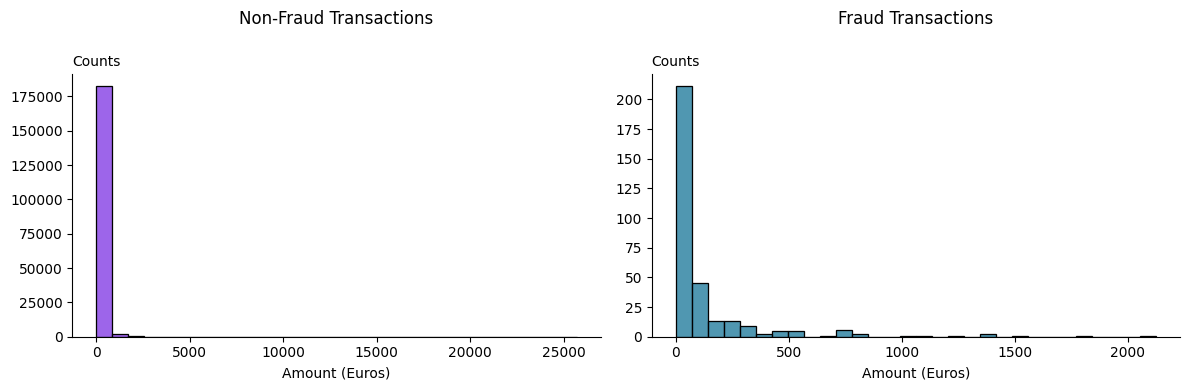

In [10]:
# Create two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Non-Fraud (outcome = 0)
sns.histplot(
    data=df[df['outcome'] == 0],
    x="Amount",
    bins=30,
    color="#7c31e4",
    ax=axes[0]
)
axes[0].set_title("Non-Fraud Transactions\n\n")
axes[0].set_xlabel("Amount (Euros)")
axes[0].set_ylabel("Counts", rotation=0, ha='left')
axes[0].yaxis.set_label_coords(0, 1.02)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Fraud (outcome = 1)
sns.histplot(
    data=df[df['outcome'] == 1],
    x="Amount",
    bins=30,
    color="#157497",
    ax=axes[1]
)
axes[1].set_title("Fraud Transactions\n\n")
axes[1].set_xlabel("Amount (Euros)")
axes[1].set_ylabel("Counts", rotation=0, ha='left')
axes[1].yaxis.set_label_coords(0, 1.02)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(f'figures/{fig_count:02d}_histograms.png', dpi=300, bbox_inches='tight')
fig_count += 1
plt.show()


### Generating Figure 2

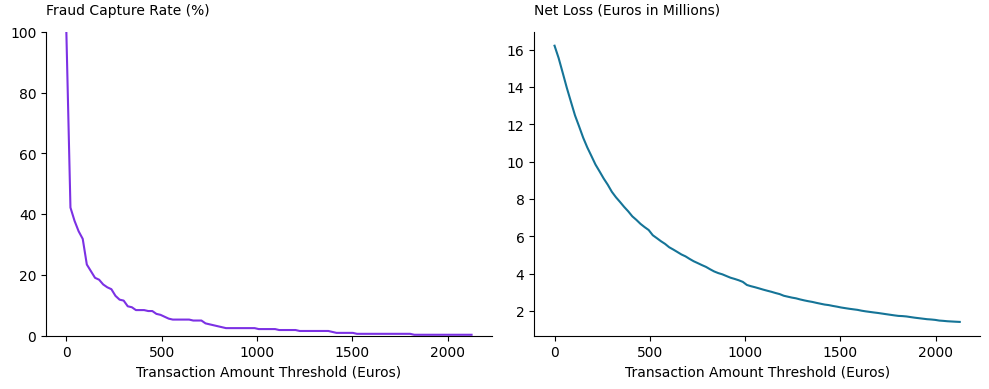

In [11]:
# Load data
y_actual = df['outcome']
is_fraud = y_actual == 1

# Threshold function
def thresholds_fraud(amounts, threshold):
    return (amounts >= threshold).astype(int)

# Define thresholds to test
min_fraud_amount = df.loc[is_fraud, 'Amount'].min()
max_fraud_amount = df.loc[is_fraud, 'Amount'].max()
thresholds = np.linspace(min_fraud_amount, max_fraud_amount, 100)

# Store metrics
fraud_capture_rates = []
detection_rates = []
net_savings = []

for t in thresholds:
    y_pred = thresholds_fraud(df['Amount'], t)
    
    # Fraud Capture Rate
    true_positives = ((y_pred == 1) & (y_actual == 1)).sum()
    actual_positives = (y_actual == 1).sum()
    fraud_capture_rate = true_positives / actual_positives if actual_positives > 0 else 0
    fraud_capture_rates.append(fraud_capture_rate)
    
    # Precision
    predicted_positives = (y_pred == 1).sum()
    precision = true_positives / predicted_positives if predicted_positives > 0 else 0
    detection_rates.append(precision)
    
    # Net Savings Score
    true_positives_mask = (y_pred == 1) & (y_actual == 1)
    false_positives_mask = (y_pred == 1) & (y_actual == 0)
    tp_sum = df.loc[true_positives_mask, 'Amount'].sum()
    fp_sum = df.loc[false_positives_mask, 'Amount'].sum()
    net_savings.append(tp_sum - fp_sum)

# Scale net savings to millions
net_savings_millions = np.array(net_savings) / 1e6
fraud_capture_rates_percent = np.array(fraud_capture_rates) * 100

# Create combined figure with 3 subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

# Fraud Capture Rate
axes[0].plot(thresholds, fraud_capture_rates_percent, color='#7c31e4')
axes[0].set_ylabel('Fraud Capture Rate (%)', rotation=0, ha='left')
axes[0].set_ylim(0, 100)

# Net Savings Score in Millions
axes[1].plot(thresholds, -net_savings_millions, color='#157497')
axes[1].set_ylabel('Net Loss (Euros in Millions)', rotation=0, ha='left')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel('Transaction Amount Threshold (Euros)')
    ax.yaxis.set_label_coords(0, 1.05)

plt.tight_layout()
plt.savefig(f'figures/{fig_count:02d}_thresholds.png', dpi=300, bbox_inches='tight')
fig_count += 1
plt.show()



### Generate Figure 4

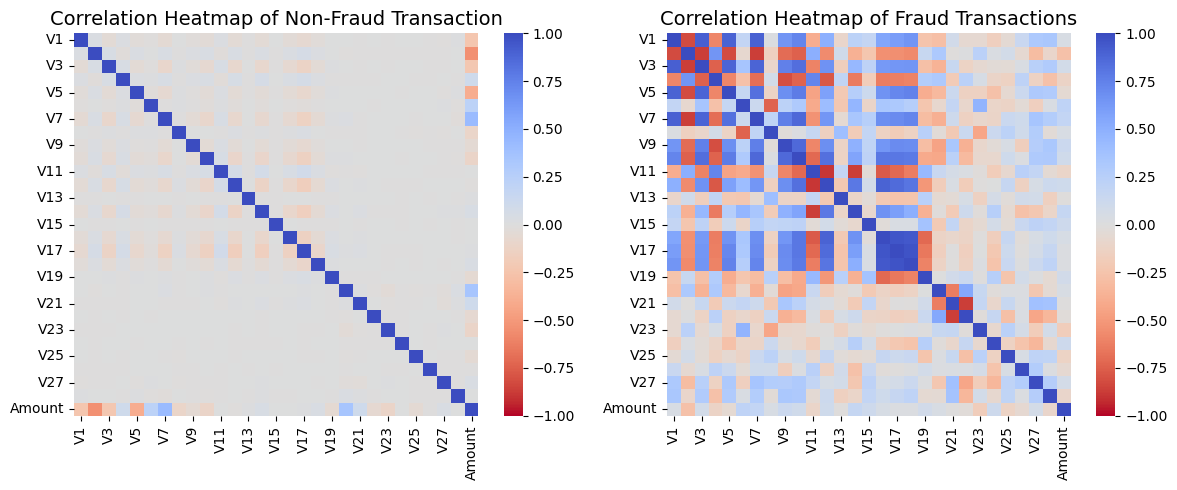

In [12]:
# Split datasets
is_fraud = df["outcome"] == 1
df_0 = df[~is_fraud]
df_1 = df[is_fraud]

# Compute correlation matrices
corr_0 = df_0.iloc[:, :-1].corr()
corr_1 = df_1.iloc[:, :-1].corr()

# Plot side-by-side heatmaps
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    corr_0,
    cmap="coolwarm_r",
    vmax=1,
    vmin=-1,
    center=0,
    annot=False,
    cbar=True,
    ax=axes[0],
)
axes[0].set_title("Correlation Heatmap of Non-Fraud Transaction", 
                  fontsize=14)

sns.heatmap(
    corr_1,
    cmap="coolwarm_r",
    vmax=1,
    vmin=-1,
    center=0,
    annot=False,
    cbar=True,
    ax=axes[1],
)
axes[1].set_title("Correlation Heatmap of Fraud Transactions", fontsize=14)

plt.tight_layout()
plt.savefig(f'figures/{fig_count:02d}_heatmap.png', dpi=300, bbox_inches='tight')
fig_count += 1
plt.show()

### Generate Figure 5

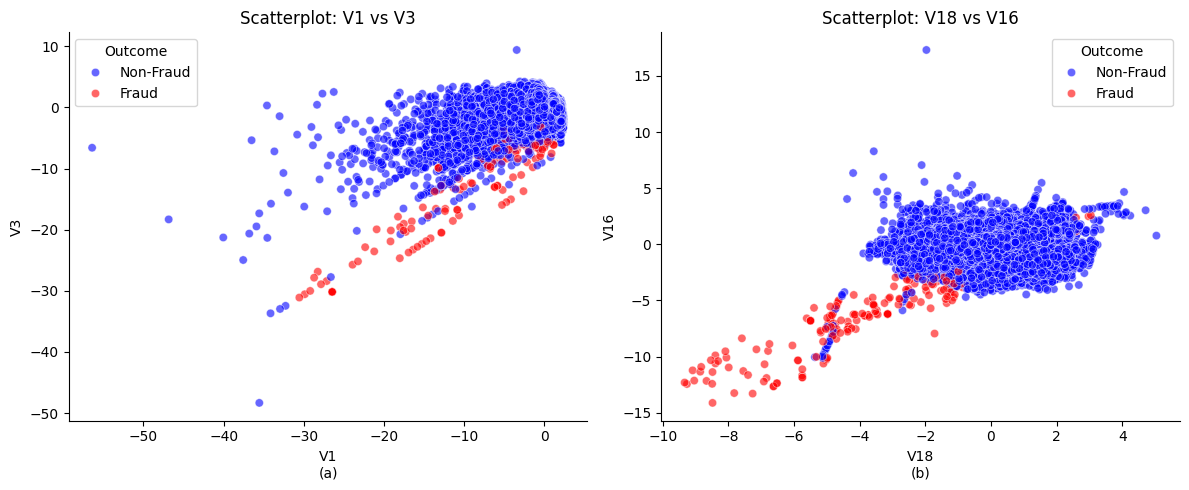

In [13]:
plt.figure(figsize=(12, 5))

# V1 vs V3
plt.subplot(1, 2, 1)
ax1 = sns.scatterplot(
    data=df, x="V1", y="V3", hue="outcome", alpha=0.6, 
    palette={0: "blue", 1: "red"}
)
legend1 = ax1.legend_
legend1.set_title("Outcome")
for t, new_label in zip(legend1.texts, ["Non-Fraud", "Fraud"]):
    t.set_text(new_label)
plt.title("Scatterplot: V1 vs V3")
ax1.set_xlabel("V1\n(a)")
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)


# V18 vs V16
plt.subplot(1, 2, 2)
ax2 = sns.scatterplot(
    data=df, x="V18", y="V16", hue="outcome", alpha=0.6, 
    palette={0: "blue", 1: "red"}
)
legend2 = ax2.legend_
legend2.set_title("Outcome")
for t, new_label in zip(legend2.texts, ["Non-Fraud", "Fraud"]):
    t.set_text(new_label)
plt.title("Scatterplot: V18 vs V16")
ax2.set_xlabel("V18\n(b)")
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(f'figures/{fig_count:02d}_scatterplot.png', dpi=300, bbox_inches='tight')
fig_count += 1
plt.show()